# INFO284 Semester Assignment Task 2

### Goal

The goal of this project is to train a convolutional neural network (CNN) to classify whether an image was created by a human or generated by Artifial Intelligence.

This is a binary image classification problem. To solve it, we use tranfser learning with a pretrained ResNet50 model from Keras

#### Why transfer learning?
Instead of training a CNN from scratch, tranfser learning reuses features learned from a large dataset such as ImageNet. This is useful because pretrained CNNs already learn important visual patterns such as edges, textures, and shapes, which can then be adapted to a new classification task.

#### Why ResNet50?
ResNet50 was chosen because it is a well-known pretrained CNN architecture available in Keras Application. It performs well on image classification tasks, and is widely used in transfer learning. Additionally, it is complex enough to extract meaningful image features without requiring us to build a full CNN from scratch

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import ResNet50

#teste forskjellige istedenfor bare ResNet50 og drøft hvilken som er best



## Model Setup
The pretrained convolutional base is loaded from ResNet50 with ImageNet weights. The original classification head is removed by setting "include_top=False". The convolutional base is frozen so that the pretrained weights are not changed during initial training.

A new classifier head is then added:
- One Dense layer with ReLU activation
- One Dropout layer for regularization
- One output Dense layer with sigmoid activation for binary classification



(weights er for forhåndstrente vekter)

In [ ]:
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])
#dette er ikke et nettverk, må endre denne. ta også med visualisering

# include_top=False betyr at vi fjerner den originale ImageNet-klassifiseringen.
# pooling="avg" gjør output lettere å sende videre til Dense-lagene.
# trainable=False betyr at vi "fryser" ResNet50 først.
# Da bruker vi modellen som feature extractor.

## Dataset 
The dataset is stored in one main folder called 'Art_shuffled', with two subfolders:
- 'AiArtData'
- 'RealArt'


Keras automatically treats these subfolders as the two classes.
The dataset is split automatically into:
- 80% training data
- 20% validation data

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42

data_dir = "Art_shuffled"

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

class_names = train_ds.class_names
print("Class names:", class_names)

# validation_split=0.2 betyr at 20% brukes til validering.
# cache() og prefetch() gjør treningen raskere.
# class_names viser rekkefølgen på klassene, som er viktig når vi tolker output senere.

Found 962 files belonging to 2 classes.
Using 770 files for training.
Found 962 files belonging to 2 classes.
Using 192 files for validation.


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

## Compiling the Model
The model is compiled with:
- **Adam** optimizer
- **binary crossentropy** loss
- **accuracy** as evaluation metric

Binary crossentripy is used because this is a binary classification task

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# binary_crossentropy brukes når vi har to klasser.
# accuracy viser hvor stor andel som blir klassifisert riktig.

### Training the Model

The model is trained on the training dataset and evaluated on the validation dataset.
At this stage, only the custom classifier head is being trained, while the pretrained ResNet50 base remaines frozen.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2
)
# verbose=2 gjør output ryddigere: én linje per epoch i stedet for masse scrolling.

Epoch 1/10


W0000 00:00:1773671717.317344 9845484 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671717.329686 9845491 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671717.522930 9845488 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671717.535779 9845484 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671717.644383 9845486 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671717.644637 9845489 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671717.689372 9845488 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671717.845362 9845490 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671718.448930 9845486 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671718.494258 9845484 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


25/25 - 34s - 1s/step - accuracy: 0.9961 - loss: 0.0387 - val_accuracy: 0.7760 - val_loss: 0.6195
Epoch 2/10


W0000 00:00:1773671751.193486 9846573 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671751.501849 9846570 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671751.733667 9846573 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671751.819986 9846572 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671751.871344 9846571 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671752.049860 9846575 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671752.098095 9846571 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671752.931666 9846569 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671752.933030 9846575 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671754.079609 9846573 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


25/25 - 35s - 1s/step - accuracy: 0.9935 - loss: 0.0322 - val_accuracy: 0.7604 - val_loss: 0.6125
Epoch 3/10


...

25/25 - 32s - 1s/step - accuracy: 0.9987 - loss: 0.0171 - val_accuracy: 0.7708 - val_loss: 0.6521
Epoch 9/10


W0000 00:00:1773671985.107794 9853357 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.115357 9853359 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.224701 9853353 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.318514 9853353 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.447265 9853354 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.494344 9853353 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.514999 9853359 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.652272 9853359 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.776845 9853357 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773671985.914107 9853358 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


25/25 - 33s - 1s/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 0.7917 - val_loss: 0.6096
Epoch 10/10


W0000 00:00:1773672017.983847 9854220 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.142210 9854215 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.166394 9854217 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.470843 9854216 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.571231 9854215 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.588427 9854216 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.592819 9854220 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.612407 9854213 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672018.996935 9854214 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672019.035813 9854216 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


25/25 - 34s - 1s/step - accuracy: 0.9987 - loss: 0.0094 - val_accuracy: 0.7969 - val_loss: 0.6634


## Training and Validation Curves

To evaluate the training process, we plot:
- training accuracy vs validation accuracy
- training loss vs validation loss


These curves help identify whether the model is learning well or overfitting.

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()


# Hvis training accuracy går opp, men validation accuracy stopper opp eller går ned,
# kan det være tegn på overfitting.
# Hvis training loss går ned, men validation loss går opp, er det også overfitting.

## Interpretation of training curves

The traning accuracy increases steadily and approaches 100%, while validation accuracy peaks earlier and then declines. At the same time, training loss continues to decrease, while validation loss increases.

This indicates **overfitting**: the model learns the training data very well, but does not generalize equally well to unseen validaton images. 


## Evaluation on the validation set

The model is evaluated on validation dataset to measure overall performance.
In addition to loss and accuracy, we also compute:
- confusion matrix
- classification report


These metrics give a clearer picture of how the model performs on each class

In [12]:
y_pred_probs = model.predict(val_ds, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)

y_true = np.concatenate([y for x, y in val_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

W0000 00:00:1774012779.418846 16784460 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012779.463257 16784460 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012779.579073 16784460 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012779.643117 16784459 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012779.689675 16784455 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012779.874564 16784461 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012779.890477 16784457 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012779.997372 16784461 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012780.014436 16784456 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1774012780.076201 16784455 png_io.cc:96] PNG warning: iCCP: known incorrect sRG

Confusion Matrix:
[[60 47]
 [41 44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.56      0.58       107
           1       0.48      0.52      0.50        85

    accuracy                           0.54       192
   macro avg       0.54      0.54      0.54       192
weighted avg       0.55      0.54      0.54       192



In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

# Dette gir oss den generelle ytelsen på valideringssettet.
# Accuracy rundt 0.75 her så lovende ut, men confusion matrix / report viste svakere generalisering.

W0000 00:00:1773672795.356017 9878725 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672795.404119 9878729 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672795.433608 9878730 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672796.026024 9878728 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672796.107442 9878728 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672796.209455 9878726 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672796.419039 9878726 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672796.723594 9878732 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672796.723917 9878725 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1773672796.754088 9878730 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 887ms/step - accuracy: 0.7969 - loss: 0.6634
Validation Loss: 0.66335529088974
Validation Accuracy: 0.796875


In [13]:
y_pred_probs = model.predict(val_ds, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)

y_true = np.concatenate([y for x, y in val_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


# y_pred_probs er sannsynligheter mellom 0 og 1.
# > 0.5 gjør dem om til klasse 0 eller 1.
# confusion_matrix viser hvilke typer feil modellen gjør.

Confusion Matrix:
[[60 47]
 [41 44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.56      0.58       107
           1       0.48      0.52      0.50        85

    accuracy                           0.54       192
   macro avg       0.54      0.54      0.54       192
weighted avg       0.55      0.54      0.54       192



## Discussion of evaluation results

The confusion matrix shows that:
- 49 real images were correctly classified
- 52 AI-generated images were correctly classified
- 58 real images were incorrectly predicted as AI
- 33 AI images were incorrectly predicted as real

This indicates that the model struggles to clearly distinguish between the two classes.

Although the validation accuracy appeared relatively high (around 79%), the confusion matrix and classification report reveal weaker performance, with an overall accuracy of approximately 54%.

This discrepancy suggests that accuracy alone is not sufficient to evaluate the model, and that a more detailed analysis is necessary. The results indicate that the model has difficulty generalizing and may rely on patterns that do not consistently separate AI-generated and human-created images.

## Testing on 5 new unseen images

To test how well the model generalizes beyond the validation set, we used 5 completely new images:
- 2 AI-generated images
- 3 human-created images

These images were not part of the training or validation dataset.

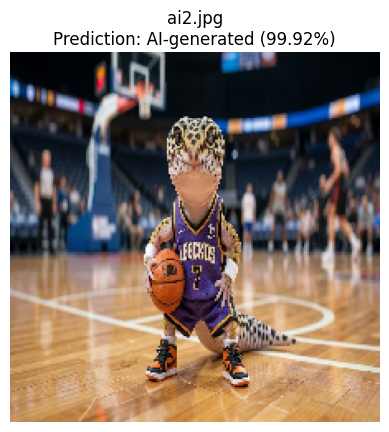

ai2.jpg: AI-generated (99.92%)


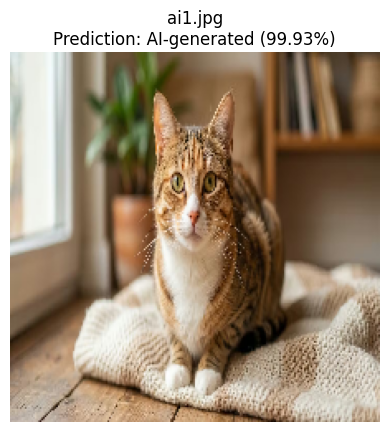

ai1.jpg: AI-generated (99.93%)


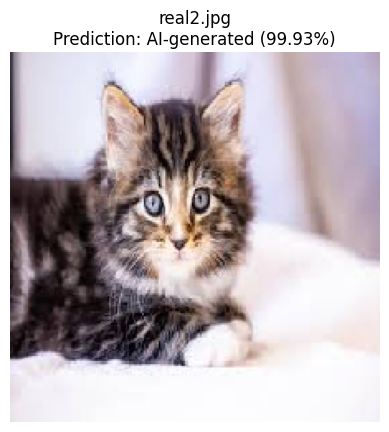

real2.jpg: AI-generated (99.93%)


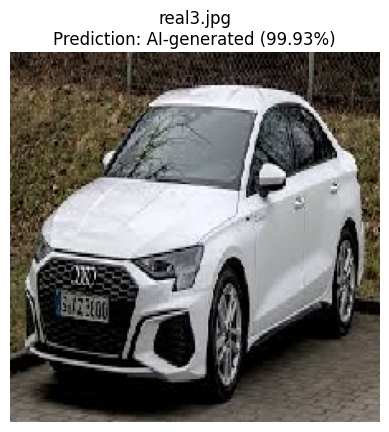

real3.jpg: AI-generated (99.93%)


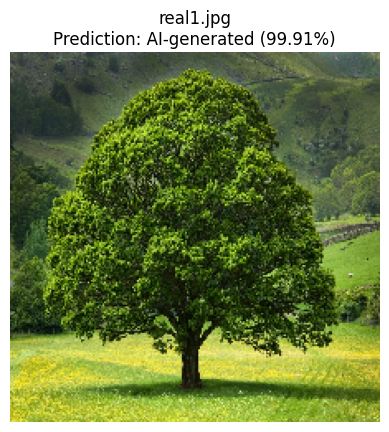

real1.jpg: AI-generated (99.91%)


In [ ]:
test_dir = "test_images"

for img_name in os.listdir(test_dir):

    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction > 0.5:
        label = "AI-generated"
        confidence = prediction
    else:
        label = "Human-created"
        confidence = 1 - prediction

    plt.imshow(img)
    plt.title(f"{img_name}\nPrediction: {label} ({confidence:.2%})")
    plt.axis("off")
    plt.show()

    print(f"{img_name}: {label} ({confidence:.2%})")

# Her tester vi modellen på helt nye bilder.
# Dette er viktig fordi oppgaven ber oss vise hvordan modellen brukes på nye input-bilder.

## Results on the 5 new images

The model predicted all 5 images as AI-generated.

Among the 5 test images:
- 2 were actually AI-generated
- 3 were actually human-created

This means the model:
- correctly classified the 2 AI-generated images
- incorrectly classified all 3 human-created images as AI-generated

External test accuracy: 2/5 = 40%

This suggests that the model has a strong tendency to over-predict the AI-generated class.

## Further Discussion

The transfer learning pipeline functioned correctly from a technical perspective:
- the dataset was loaded successfully
- the pretrained ResNet50 model was reused as a feature extractor
- the classifier head was trained
- validation and external test results were computed

However, the model’s performance was limited.

The validation curves showed clear signs of overfitting, and the external test on 5 unseen images showed weak generalization. In particular, the model tended to classify real images as AI-generated.

A possible explanation is that the model learned features that were too strongly associated with AI-generated images, which led to false positives on real images. Another explanation is that the dataset may be too difficult or too limited for the current setup.